# LINMA2470 – Stochastic Modelling – Project Part I

**Group Member:** Lore Lernoux, Anthony Richelle, Brieuc Dallemagne, Tessa Rouvez   
**NOMA:** 77562000, 39962400, 77122100, 3772100 

This notebook presents our implementation for Part I of the LINMA2470 project. The goal is to explore Reinforcement Learning (RL) techniques for solving a simplified inventory management problem modeled as a Markov Decision Process (MDP).  

The structure of this notebook follows the required deliverables:

1. Implementation of the MDP environment.  
2. Implementation of Q-learning and SARSA with ε-greedy exploration.  
3. Testing with various learning and exploration rates.  
4. Comparison with POMDPs.jl package implementations.  
5. Solving the problem using value iteration (or LP) and comparing optimal policies.


In [ ]:
using Pkg
# Pkg.add("Statistics")
#Pkg.add("Plots")
# Pkg.add("POMDPs")
# Pkg.add("POMDPTools")
# Pkg.add("QuickPOMDPs")
# Pkg.add("DiscreteValueIteration")
# Pkg.add("TabularTDLearning")
# Pkg.add("Distributions")
# Pkg.add("JuMP")
# Pkg.add("GLPK")

## 1.1 MDP Environment Implementation

This section defines the environment of the inventory management problem as a Markov Decision Process (MDP).  

- **States:** inventory levels (0 to 20)  
- **Actions:** order bikes (1) or not (0)  
- **Rewards:** include holding cost, stockouts, and ordering cost  


Here is a description of how the generating function and the modilisation is done. First let's understand how a day in the shop works : 
1. 9 am : If bikes were ordered the day before, they now arrive.
2. 9am-5pm : People come to buy bikes (between 0 and 10).
3. 6pm : If needed, order 5 new bikes. 

It is important to understand that the state $s'$ starts at 6pm as no new demand is issued. The ordered bikes come just before the demand quicks in so we could describe one turn as : 
1. 5pm : See what the current stock is
2. 6pm : Order bikes if needed
3. Night : Pay holding costs on the bikes 
4. 9am : New bikes arrive 
5. Day : Pay penalities on unmet demand
6. 5pm : End of the turn and start the next one


In [ ]:
function generative_function2(s::Int, a::Int, rng=Random.GLOBAL_RNG, demand::Int=-1; verbose=false) 

    s = min(s + 5 * a, 20)
    if demand == -1 demand = rand(rng, 0:10) end # Allows for a deterministic outcome
    if verbose println("Demand: $demand") end

    lost_sale = 50 * max(demand - s, 0) # If we don't have enough bikes to satisfy the demand 
    next_state = max(s - demand, 0) #What we have left after the demand, can't be negative

    holding = max(2 * min(s - demand, 10) + 4 * max(s - demand - 10, 0), 0)
    transport = a == 1 ? 20 : 0

    total = holding + transport + lost_sale
    
    return (sp=next_state, r=-total)
end

function generative_function(s::Int, a::Int, rng=Random.GLOBAL_RNG, demand::Int=-1; verbose=false) 

    holding = 2 * min(s, 10) + 4 * max(s - 10, 0)
    s = min(s + 5 * a, 20)
    
    if demand == -1 demand = rand(rng, 0:10) end # Allows for a deterministic outcome
    if verbose println("Demand: $demand") end

    lost_sale = 50 * max(demand - s, 0) # If we don't have enough bikes to satisfy the demand 
    next_state = max(s - demand, 0) #What we have left after the demand, can't be negative
    transport = a == 1 ? 20 : 0

    total = holding + transport + lost_sale
    
    return (sp=next_state, r=-total)
end

generative_function (generic function with 3 methods)

In [3]:
using Random

actions = [0, 1]
current_state = 10
# current_state, r = generative_function(10, 0)
# println("Step 1: State = $current_state, Action = 0, Next State = $current_state, Reward = $r \n")
for step in 1:5
    action = rand(actions)
    result = generative_function(current_state, action, verbose=true)

    println("Step $step: State = $current_state, Action = $action, Next State = $(result.sp), Reward = $(result.r) \n")

    current_state = result.sp
end

Demand: 1
Step 1: State = 10, Action = 0, Next State = 9, Reward = -20 

Demand: 10
Step 2: State = 9, Action = 1, Next State = 4, Reward = -38 

Demand: 4
Step 3: State = 4, Action = 0, Next State = 0, Reward = -8 

Demand: 3
Step 4: State = 0, Action = 1, Next State = 2, Reward = -20 

Demand: 10
Step 5: State = 2, Action = 0, Next State = 0, Reward = -404 



Let's also write the following function that will simulate a given policy over a certain time and from a given initial state. It will then return the average reward per turn. The other function here will be used to extract a policy from a Q-table.

In [4]:
struct InventoryMDP
    states::Vector{Int}
    actions::Vector{Int}
    γ::Float64
end

function simulate_pol(policy, num_it, inital_state)
    s = inital_state 
    r_tot = 0.0
    for step in 1:num_it 
        sp, r = generative_function(s, policy[s])
        r_tot += r
        s = sp
    end
    return r_tot / num_it
end

function extract_policy(mdp::InventoryMDP, Q::Matrix)
    policy = Dict{Int, Int}()
    for s in mdp.states
        policy[s] = argmax(Q[s + 1, :]) - 1
    end
    return policy
end

extract_policy (generic function with 1 method)

## 1.2 Q-Learning Implementation

This section implements the Q-learning algorithm with ε-greedy exploration.  

### Overview of Q-Learning
Q-learning is a model-free reinforcement learning algorithm that learns the optimal policy for an agent interacting with an environment. The agent learns by updating Q-values, which represent the expected cumulative reward for taking an action `a` in a state `s` and following the optimal policy thereafter.

The Q-value update is based on the Bellman equation:

$
Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]
$

Where:
- $ Q(s, a) $: Current Q-value for state `s` and action `a`.
- $ \alpha $: Learning rate, which controls how much new information overrides old information.
- $ r $: Reward received after taking action `a` in state `s`.
- $ \gamma $: Discount factor, which determines the importance of future rewards.
- $ \max_{a'} Q(s', a') $: Maximum Q-value for the next state `s'` over all possible actions.

### ε-Greedy Exploration
To balance exploration and exploitation, the ε-greedy strategy is used:
- In most cases, the $Q$ value will be updated using the action that is considered the best at the moment considering the current $Q$ table.
- With probability $ \varepsilon $, the agent will instead selects a random action to explorate new possibilities.

### Implementation Details
1. **State and Action Space**:
   - The state space represents the inventory levels (e.g., 0 to 20 bikes).
   - The action space includes two actions: `0` (do nothing) and `1` (add 5 bikes to the inventory).

2. **Generative Function**:
   - The generating function generates the next state and the reward from the current state and the aciton taken.
   - It penalizes the agent for lost sales, holding excess inventory and transportation costs when asking for new bikes.

3. **Algorithm Parameters**:
   - `num_episodes`: Number of episodes to train the agent.
   - `max_steps`: Number of steps per episode.
   - `α`: Learning rate.
   - `ε`: Exploration rate.
   - `eval_period` : Frequency at which the policy is evaluated.
   - `neval` : Number of steps per simulation.
   - `num_sim` : Number of simulations of the policy.

4. **Training**:
   - The agent interacts with the environment for a specified number of episodes.
   - At the start of each episode, the starting point is chosen randomly to allow for better exploration of the different possibilites and avoid the agent being stuck in a few states.
   - Q-values are updated iteratively using the Bellman equation.

5. **Output**:
   - The learned Q-table, which can be used to derive the optimal policy.
   - The evalutation of the policy every `eval_period` number of episode.

This implementation demonstrates how Q-learning can be applied to solve inventory management problems under uncertainty.

In [5]:
function q_learning(mdp::InventoryMDP; α::Float64, ε::Float64, num_episodes::Int, max_steps::Int, eval_period::Int=1000, neval::Int=1, num_sim::Int=100)
    Q = zeros(length(mdp.states),length(mdp.actions))
    perf_eval = []
    for episode in 1:num_episodes # Number of times we run the algorithm
        s = rand(mdp.states) # Initial number of bikes is random (--> dans l'énoncé pour moi c'est 10)
        for step in 1:max_steps
            a = rand() < ε ? rand(mdp.actions) : argmax(Q[s+1, :]) - 1
            
            (sp, r) = generative_function(s, a)
            Q[s+1, a+1] += α *(r + mdp.γ * maximum(Q[sp+1, :]) - Q[s+1, a+1])
            s = sp
        end

        if episode % eval_period == 0
            policy = extract_policy(mdp, Q)
            reward_avg = 0.0
            for i in 1:num_sim
                reward_avg += simulate_pol(policy, neval, 10) / num_sim
            end
            push!(perf_eval, reward_avg)
        end
    end
    return Q, perf_eval
end


q_learning (generic function with 1 method)

## 1.3 SARSA Implementation

SARSA (State-Action-Reward-State-Action) is very similar to Q-learning, as both are reinforcement learning algorithms that aim to learn the optimal policy by updating Q-values. However, there are some key differences between the two:

### Key Differences Between SARSA and Q-Learning
1. **On-Policy vs. Off-Policy**:
   - SARSA is an **on-policy** algorithm, meaning it updates the Q-values based on the action actually taken by the agent in the next state, following the current policy.
   - Q-learning, on the other hand, is **off-policy**, meaning it updates the Q-values based on the maximum possible reward for the next state, assuming the agent always acts optimally.

2. **Q-Value Update**:
   - In SARSA, the Q-value update uses the next action $ a' $ chosen by the agent's current policy:
     $
     Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma Q(s', a') - Q(s, a) \right]
     $

3. **Exploration Sensitivity**:
   - SARSA is more sensitive to the agent's exploration strategy (e.g., ε-greedy). If the agent explores risky actions, SARSA will reflect this in its updates, making it more conservative in environments where exploration can lead to bad outcomes.
   - Q-learning assumes the agent will always act optimally in the future, which can make it faster but less stable in some environments.



In [6]:
function sarsa(mdp::InventoryMDP; α::Float64, ε::Float64, num_episodes::Int, max_steps::Int, eval_period::Int=1000, neval::Int=1, num_sim::Int=100)
    Q = zeros(length(mdp.states),length(mdp.actions))
    perf_eval = []

    for episode in 1:num_episodes #Number of times we run the algorithm
        # s = rand(mdp.states) #Initial number of bikes is random (--> dans l'énoncé pour moi c'est 10)
        s = 10 # rand(mdp.states)
        a = rand() < ε ? rand(mdp.actions) : argmax(Q[s+1, :]) - 1 #We take a random action or the action that maximizes the Q value
        
        for step in 1:max_steps

            result = generative_function(s, a) # use action a and observe r and sp
            next_state, r = result.sp, result.r

            ap = rand() < ε ? rand(mdp.actions) : argmax(Q[next_state+1, :]) - 1 #We take a random action or the action that maximizes the Q value for the next state

            Q[s+1,a+1]+= α *(r + mdp.γ *Q[next_state+1, ap+1] - Q[s+1, a+1])

            s, a = next_state, ap
        end

        if episode % eval_period == 0
            policy = extract_policy(mdp, Q)
            reward_avg = 0.0
            for i in 1:num_sim
                reward_avg += simulate_pol(policy, neval, 10) / num_sim
            end
            push!(perf_eval, reward_avg)
        end
    end
    return Q, perf_eval
end 

sarsa (generic function with 1 method)

## 2 Parameter Sensitivity Tests ($\alpha$ and ε)

We evaluate the impact of different learning rates ($\alpha$) and exploration rates (ε) on the convergence and performance of both algorithms.  

The sets tested are:  

- $\alpha \in \{0.2, 10^{-1}, 10^{-2}, 10^{-5}\} $
- $\varepsilon \in \{0.2, 10^{-1}, 10^{-2}, 10^{-5}\} $

For each combination of (α, ε), we:
- Ran multiple training episodes.
- Recorded the average reward of the policy at different points in the the training process.
- Extracted the final learned policy.

#### Observations and Interpretation
- High learning rates make need information heavily influence the Q-values, this may lead to a faster convergence but also a lot more instability.

- Low learning rates make the algorithm a lot slower but a lot more precise. The final result will be very stable given that the algorithm has had many iterations to converge.

Typically, $\alpha=10^{-5}$ was found to be really slow to converge and gave bad results given our number of iterations and $\alpha=0.2$ gave quite unstable results.

- High exploration rates (e.g., ε = 0.2) allows the algorithm to explore more possibilities and more different policies allowing it to potentially find a better outcome (finding a better minimum). But as we dont reduce it with the number of epsiode, it also leads to a higher variability in the final solution as even when the agent as found a good policy it will continue exploring.

- Low exploration rates (e.g., ε = 0.00001) make the algorithm exploit the good policies it found early on without searching too much for something that could be better and widely different. This may lead to a bad convergence as the algorithm is unable to try new things.

The ideal algorithm would leverage both of these by having a variable exploration rate, making it able to explore a lot of policies early on and then by decreasing the exploration rate progressivly to explore that solution locally.

After taking the different tradeoffs into considerations, α = 1e-2 and ε = 1e-2 seems to be a good choice because it does not need millions of iterations to find a good policy and is a good middleground in terms of exploration.

In [7]:
num_episodes = 100
max_steps = 100000
env = InventoryMDP(0:20, [0, 1], 0.99)

alphas = [0.2, 0.1, 1e-2, 1e-5]
epsilons = [0.2, 0.1, 1e-2, 1e-5]

res_q = []
res_s = []

# Performance evaluation parameters
eval_period = 5
neval = 1000
num_sim = 1000

for (a_idx, α) in enumerate(alphas)
    for (e_idx, ε) in enumerate(epsilons)
        q, rewards = q_learning(env, α=α, ε=ε, num_episodes=num_episodes, max_steps=max_steps, eval_period=eval_period, neval=neval, num_sim=num_sim)
        push!(res_q, (α=α, ε=ε, rewards=rewards, q=q))

        q, rewards = sarsa(env, α=α, ε=ε, num_episodes=num_episodes, max_steps=max_steps, eval_period=eval_period, neval=neval, num_sim=num_sim)
        push!(res_s, (α=α, ε=ε, rewards=rewards, q=q))
    end
end

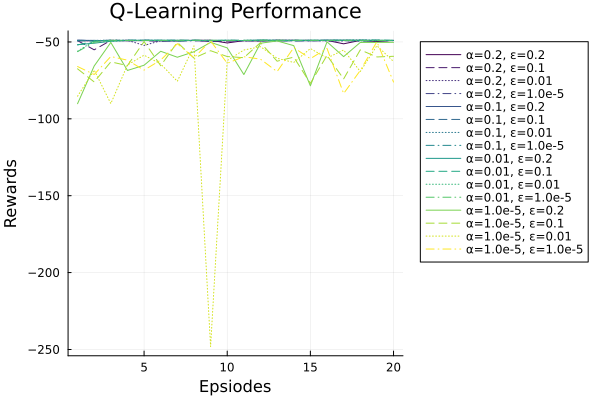

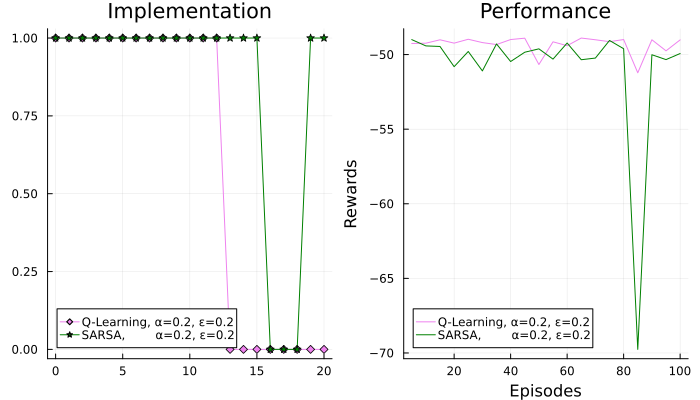

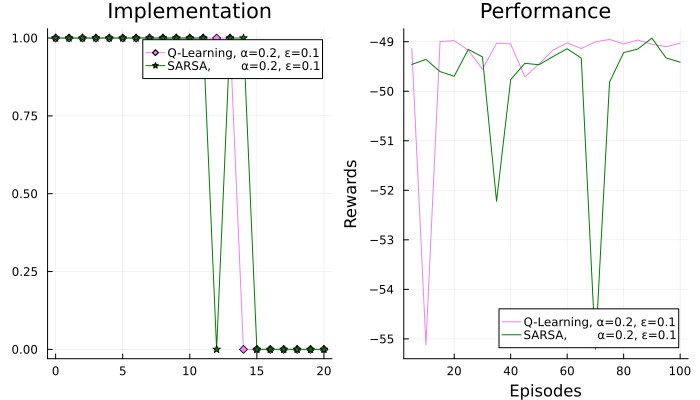

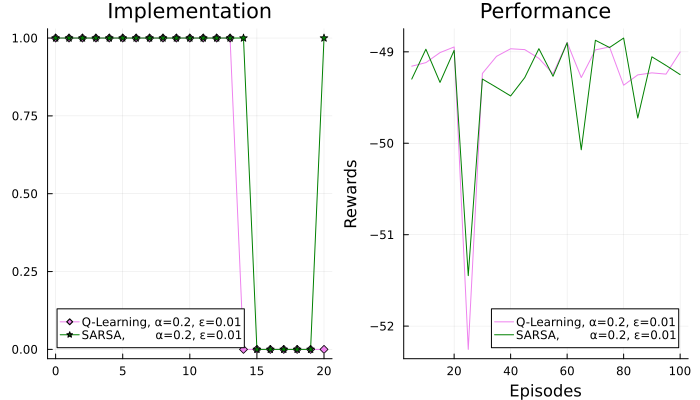

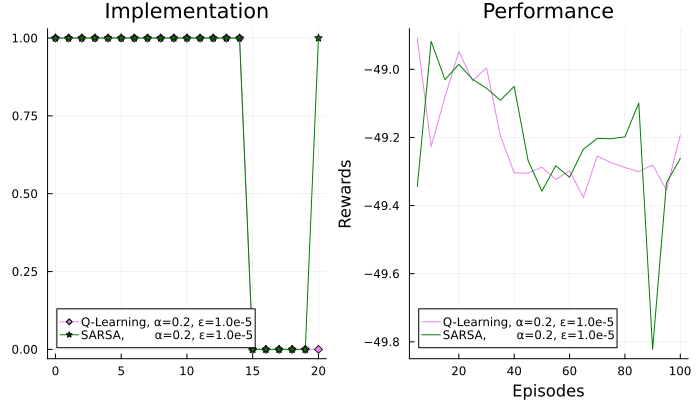

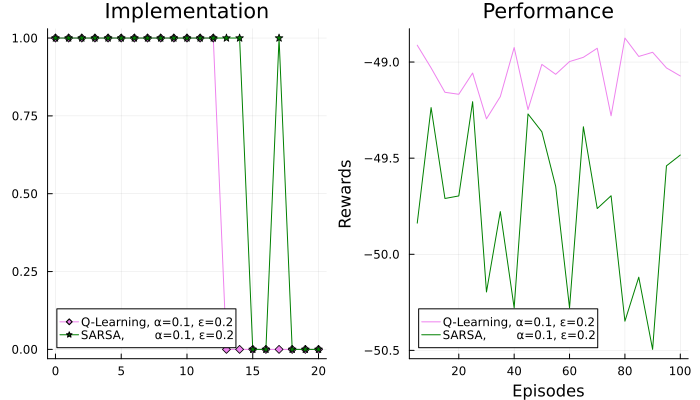

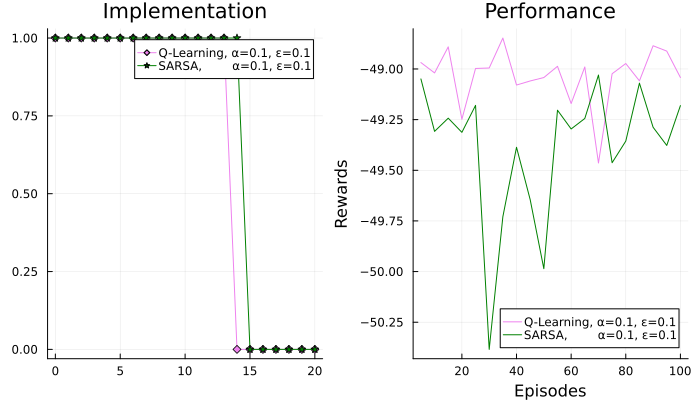

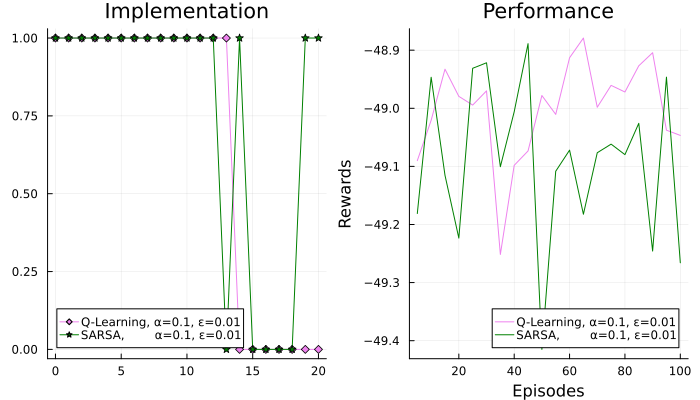

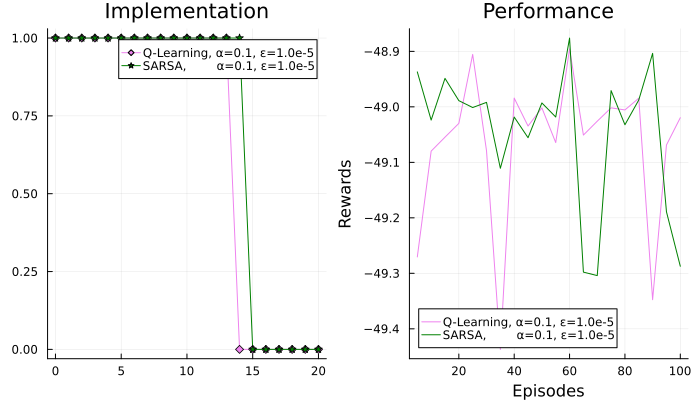

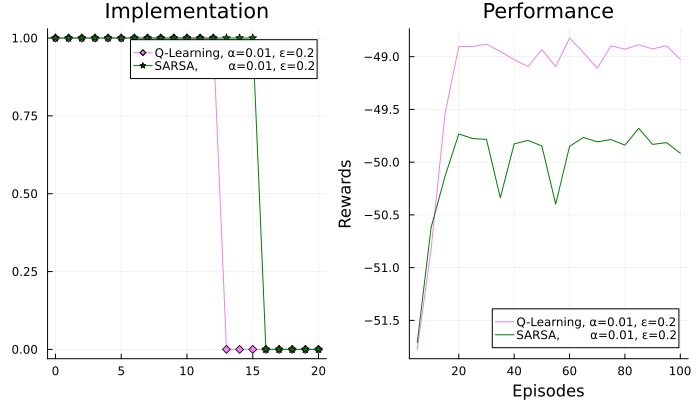

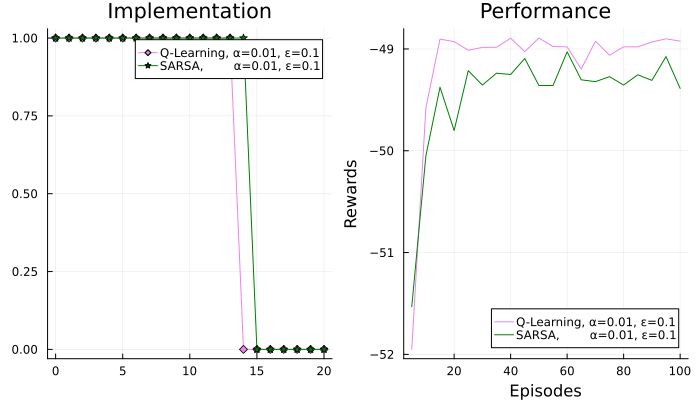

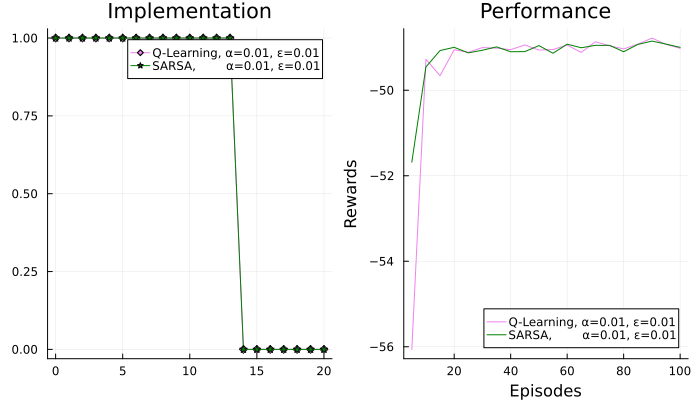

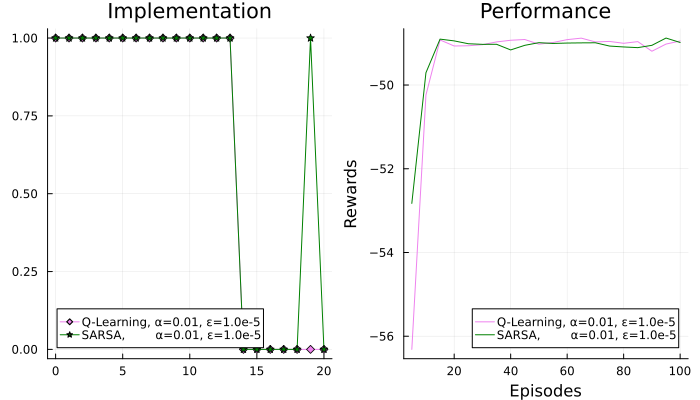

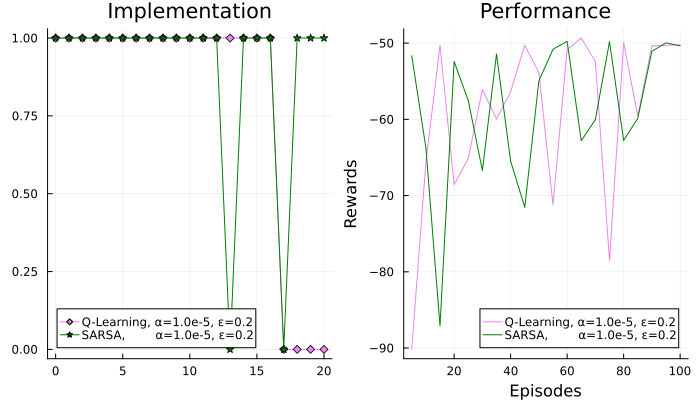

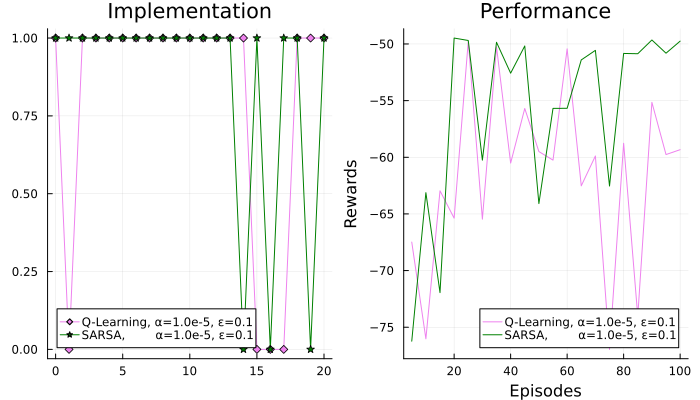

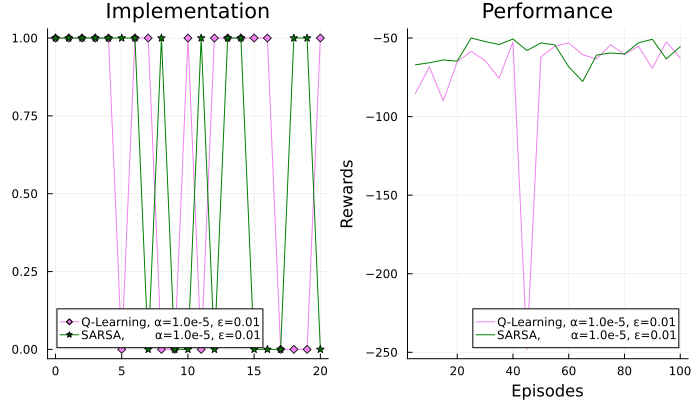

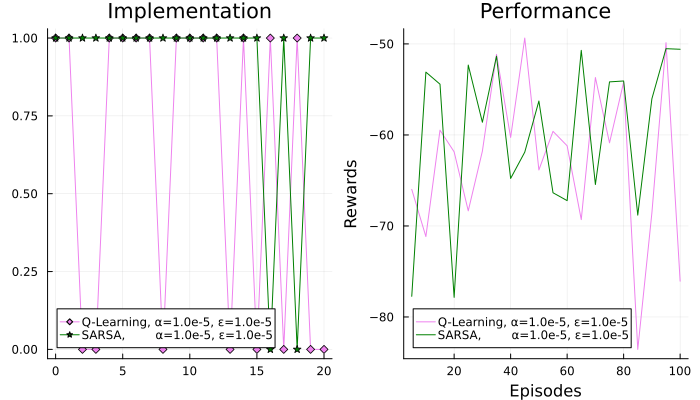

In [15]:
using Statistics
using Plots

plt = plot(title="Q-Learning Performance",
           xlabel="Epsiodes",
           ylabel="Rewards",
           legend=:outertopright)

colors = palette(:viridis, length(alphas) * length(epsilons))
linestyles = [:solid, :dash, :dot, :dashdot]


for i in 1:length(res_q)
    plot!(plt,
            res_q[i].rewards,
            label="α=$(res_q[i].α), ε=$(res_q[i].ε)",
            color=colors[i],
            linestyle=linestyles[(i - 1) % length(linestyles) + 1])
    
end

display(plt)


for i in 1:length(res_q)
    policyq = extract_policy(env, res_q[i].q)
    policys = extract_policy(env, res_s[i].q)
    x = sort(collect(keys(policyq)))
    xep = eval_period:eval_period:(num_episodes - num_episodes % eval_period)
    yq = [policyq[k] for k in x]
    ys = [policys[k] for k in x]

    p1 = plot(x, yq, title="Implementation", marker=:diamond, color="violet", label="Q-Learning, α=$(res_s[i].α), ε=$(res_s[i].ε)")
    plot!(x, ys, marker=:star5, color="green", label=                               "SARSA,        α=$(res_q[i].α), ε=$(res_q[i].ε)")
    p2 = plot(xep, res_q[i].rewards, color="violet", label="Q-Learning, α=$(res_q[i].α), ε=$(res_q[i].ε)", xlabel="Episodes", ylabel="Rewards", title="Performance")
    plot!(xep, res_s[i].rewards, color="green",      label="SARSA,        α=$(res_q[i].α), ε=$(res_q[i].ε)", xlabel="Episodes", ylabel="Rewards", title="Performance")
    combined = plot(p1, p2, layout=(1, 2), size=(700, 400))
    display(combined)
end

### 3. Comparison with TabularTDLearning.jl (QuickPOMDPs & POMDPs.jl)

In this section, we compare our custom implementations of Q-learning and SARSA with the official solvers provided by the JuliaPOMDP ecosystem.

We used:
- `QuickPOMDPs.jl` to define the Markov Decision Process representing the inventory control environment.
- `TabularTDLearning.jl` to run the Q-learning and SARSA algorithms.

In order to ensure a fair comparison between the Q-learning and SARSA implementations, we used the same parameter settings for both algorithms. The key parameters used in the experiments are as follows:

- **Learning Rate (α)**: 1e-2 
- **Exploration Rate (ε)**: 1e-2
- **Number of Episodes**: 100
- **Maximum Steps per Episode**: 100 000

The following tables show the absolute differences in Q-values for each (state, action) pair. A checkmark ("✓") indicates that the values are identical (up to a numerical tolerance), while a cross ("✗") highlights discrepancies.
This allows us to verify whether both implementations converged to the same value function and assess the precision of the learned policies.


#### Results : Q_learning and Sarsa

Note that both learning processes are inherently random and it is normal to have sometimes differences in final policies due to small changes in the final values in our Q-tables. Even when the relative difference between both algorithms is about $1%$ this may have an impact on the final policy as some states have very closes Q-values when taking either action.

- **Q-learning** : The policy generated by our custom Q-learning implementation showed a **100% match** with the policy obtained from the `TabularTDLearning.jl` library.  This perfect alignment confirms that Q-learning consistently converged to the same optimal policy, despite its off-policy nature. Its updates, based on the best estimated Q-values, likely helped stabilize the learning process in this environment.

- **SARSA** : the policy from our custom SARSA implementation matched **95.24%** with the library's version.  
  While still very close, this slight deviation is expected: being on-policy, SARSA updates its Q-values based on the **actual exploratory actions** taken. This makes it more sensitive to stochastic effects and ε-greedy decisions during training, which can lead to subtle differences in convergence.

In [50]:
using POMDPTools
using QuickPOMDPs
using TabularTDLearning
using Distributions
using Random
using POMDPs: action, value, simulate
using Printf

function comp_q_learning(; α::Float64, ε::Float64, num_episodes::Int, max_steps::Int)
    rng = Random.default_rng()
    bike_mdp = QuickMDP(
        generative_function,
        states = 0:20, 
        actions = [0, 1],
        discount = 0.99,
        initialstate = 0:20 # start with 10 bikes
)
    # println("MDP_POMDP: $bike_mdp \n")
    pck_q_learning = QLearningSolver(
        exploration_policy=EpsGreedyPolicy(bike_mdp, ε),
        learning_rate=α, 
        n_episodes=num_episodes, 
        max_episode_length=max_steps, 
        eval_every=10000, 
        n_eval_traj=1,
        verbose=false)
    return solve(pck_q_learning, bike_mdp)
end

comp_q_learning (generic function with 1 method)

In [ ]:
mdp = InventoryMDP(0:20, [0, 1],0.99) #Number of bikes, actions: 0 (don't order), 1 (order 5 bikes), discount factor: 0.99

α = 1e-2 #1e-2 # Can take values in [0.2, 0.1, 1e-2, 1e-5]
ε = 1e-2 #1e-5 # Can take values in [0.2, 0.1, 1e-2, 1e-5]
num_episodes = 100 # Number of episodes to run the algorithm
max_steps = 100000

# Run both implementations
Q_learning_table, rew = q_learning(mdp, α=α, ε=ε, num_episodes=num_episodes, max_steps=max_steps)
qlearn_POMPD = comp_q_learning(α=α, ε=ε, num_episodes=num_episodes, max_steps=max_steps)

# Create a comparison table
println("\nState-by-state policy comparison:")
println("State | Lib Action | Our Action | Match? | ")
println("-------------------------------------------")
matches = 0
for s in 0:20
    lib_action = action(qlearn_POMPD, s)
    our_action = argmax(Q_learning_table[s + 1, :]) - 1
    match_indicator = (lib_action == our_action) ? "✓" : "✗"
    matches += lib_action == our_action

    @printf("%5d |     %d      |      %d     |    %s   |\n",
        s, our_action, lib_action, match_indicator)
end
println("\nMatch percentage: $(100 * matches / 21)%")

diff = abs.(Q_matrix .- qlearn_POMPD.value_table)
denom = abs.(qlearn_POMPD.value_table) .+ 1e-8  # Avoid divide by zero
rel_diff = diff ./ denom

mean_rel_diff = mean(rel_diff)
max_rel_diff = maximum(rel_diff)

println("Mean relative difference in Q-values: $(round(mean_rel_diff, digits=4))")
println("Max relative difference in Q-values: $(round(max_rel_diff, digits=4))")

heatmap(
    0:20, 0:1,
    rel_diff,
    yticks = [0, 1],
    xticks = 0:20,
    xlabel = "State",
    ylabel = "Action",
    title = "Relative Difference: Our Q-Learning vs Library",
    colorbar_title = "Rel. Diff",
    c = :viridis,
    size = (700, 400),
    yflip = true 
)


In [11]:
function comp_sarsa(; α::Float64, ε::Float64, num_episodes::Int, max_steps::Int)
    rng = Random.default_rng()
    bike_mdp = QuickMDP(
        generative_function,
        states = 0:20, 
        actions = [0, 1],
        discount = 0.99,
        initialstate = 0:20
    )

    # SARSA solver
    sarsa_solver = SARSASolver(
        exploration_policy=EpsGreedyPolicy(bike_mdp, ε),
        learning_rate=α,
        n_episodes=num_episodes,
        max_episode_length=max_steps,
        eval_every=10000,
        n_eval_traj=1,
        verbose=false
    )

    return solve(sarsa_solver, bike_mdp)
end

comp_sarsa (generic function with 1 method)

SARSA policy:

State | Our Action | Lib Action | Match? |
-------------------------------------------------------
    0 |     1      |      1     |    ✓   |
    1 |     1      |      1     |    ✓   |
    2 |     1      |      1     |    ✓   |
    3 |     1      |      1     |    ✓   |
    4 |     1      |      1     |    ✓   |
    5 |     1      |      1     |    ✓   |
    6 |     1      |      1     |    ✓   |
    7 |     1      |      1     |    ✓   |
    8 |     1      |      1     |    ✓   |
    9 |     1      |      1     |    ✓   |
   10 |     1      |      1     |    ✓   |
   11 |     1      |      1     |    ✓   |
   12 |     1      |      1     |    ✓   |
   13 |     1      |      1     |    ✓   |
   14 |     0      |      0     |    ✓   |
   15 |     0      |      0     |    ✓   |
   16 |     0      |      0     |    ✓   |
   17 |     0      |      0     |    ✓   |
   18 |     0      |      0     |    ✓   |
   19 |     0      |      0     |    ✓   |
   20 |     0      |      

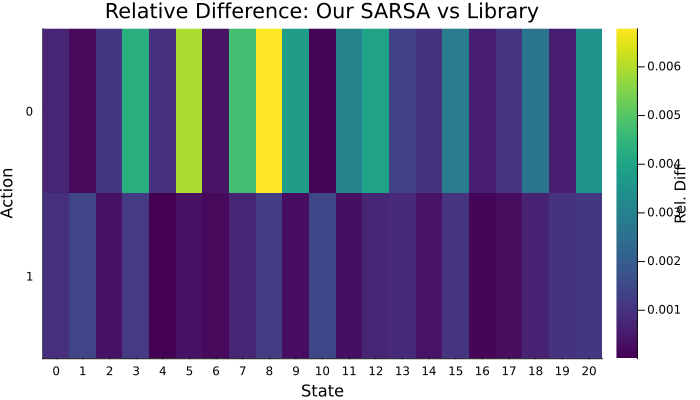

In [43]:
using Printf
using Plots
using Statistics

# Run both SARSA implementations
Q_matrix, _ = sarsa(mdp, α=α, ε=ε, num_episodes=num_episodes, max_steps=max_steps)
sarsa_POMDP = comp_sarsa(α=α, ε=ε, num_episodes=num_episodes, max_steps=max_steps)

# Action-by-action comparison
println("SARSA policy:\n")
println("State | Our Action | Lib Action | Match? |")
println("-------------------------------------------------------")

matches = 0
for s in 0:20
    lib_action = action(sarsa_POMDP, s)
    our_action = argmax(Q_matrix[s + 1, :]) - 1  # Julia is 1-indexed
    match_indicator = (lib_action == our_action) ? "✓" : "✗"
    matches += (lib_action == our_action)

    @printf("%5d |     %d      |      %d     |    %s   |\n",
        s, our_action, lib_action, match_indicator)
end

println("\nMatch percentage: $(round(100 * matches / 21, digits=1))%")

diff = abs.(Q_matrix .- sarsa_POMDP.value_table)
denom = abs.(sarsa_POMDP.value_table) .+ 1e-8  # Avoid divide by zero
rel_diff = diff ./ denom

mean_rel_diff = mean(rel_diff)
max_rel_diff = maximum(rel_diff)

println("Mean relative difference in Q-values: $(round(mean_rel_diff, digits=4))")
println("Max relative difference in Q-values: $(round(max_rel_diff, digits=4))")

heatmap(
    0:20, 0:1,
    rel_diff,
    yticks = [0, 1],
    xticks = 0:20,
    xlabel = "State",
    ylabel = "Action",
    title = "Relative Difference: Our SARSA vs Library",
    colorbar_title = "Rel. Diff",
    c = :viridis,
    size = (700, 400),
    yflip = true 
)


### 4. Solving the MDP via Linear Programming

To benchmark our reinforcement learning solutions, we computed the optimal policy using a **Linear Programming (LP) approach**. This method solves the Bellman optimality equations by minimizing the total expected cost under the constraints imposed by the transition probabilities and reward function.

The LP method used:
- A precomputed reward table `R[(s, a)]` and transition probability table `P[(s, a, s′)]` based on deterministic simulation of demand.
- A JuMP model with GLPK as the solver.

The resulting policy was then compared against:
- Our Q-learning implementation.
- Our SARSA implementation.

We summarized the comparison in a table with one row per state (from 0 to 20). The policy actions from each method were listed, and a match indicator was computed.

#### Policy Comparison Summary

- SARSA vs LP match: 95.2%
- All three (SARSA, Q-learning, LP) match: 95.2%
- For most states, all three methods recommend the same action, showing that Q-learning and SARSA have successfully learned near-optimal policies.
- The only discrepancy occurs at **state 13**, where LP recommends *not* ordering (action = 0), while both Q-learning and SARSA choose to order. This may be due to slight overestimation of expected costs in that state.
- The average cost from simulating the LP policy over 1000 steps was **-45.46**, which is a good indicator of the optimal policy’s performance in terms of cost management.

This confirms that learning-based approaches can closely approximate optimal policies even in the absence of full environment knowledge.



In [13]:
using JuMP
using GLPK

function compute_RP(mdp::InventoryMDP, demand_values=0:10)
    rnd = Random.default_rng()
    R = Dict{Tuple{Int, Int}, Float64}() 
    P = Dict{Tuple{Int, Int, Int}, Float64}()

    unit_prob = 1 / length(demand_values)

    for s in mdp.states
        for a in mdp.actions
            R[(s, a)] = 0.0
            transis = Dict{Int, Float64}()

            for d in demand_values
                sp, r = generative_function(s, a, rnd, d)
                R[(s, a)] += unit_prob * r
                transis[sp] = get(transis, sp, 0.0) + unit_prob # add one occurence
            end

            for (sp, p) in transis
                P[(s, a, sp)] = p
            end
        end
    end

    return R, P
end

function solve_mdp_lp(mdp::InventoryMDP)
    R, P = compute_RP(mdp)
    model = Model(GLPK.Optimizer)
    set_silent(model)

    # Decision variables: V[s] = value of state s
    @variable(model, V[s in mdp.states])

    # Objective: minimize sum of V(s)
    @objective(model, Min, sum(V[s] for s in mdp.states))

    # Bellman constraints: V(s) ≥ R(s,a) + γ ∑ P(s'|s,a) * V(s')
    for s in mdp.states
        for a in mdp.actions
            rhs = R[(s, a)] + mdp.γ * sum(get(P, (s, a, sp), 0.0) * V[sp] for sp in mdp.states)
            @constraint(model, V[s] ≥ rhs)
        end
    end

    optimize!(model)

    V_opt = Dict(s => JuMP.value(V[s]) for s in mdp.states)

    # Derive greedy policy: π(s) = argmax_a Q(s,a)
    policy = Dict{Int, Int}()
    for s in mdp.states
        policy[s] = argmax(Dict(a => R[(s, a)] + mdp.γ * sum(get(P, (s, a, sp), 0.0) * V_opt[sp] for sp in mdp.states) for a in mdp.actions))
    end

    return V_opt, policy
end

solve_mdp_lp (generic function with 1 method)

In [ ]:
table_q, _ = q_learning(mdp, α=α, ε=ε, num_episodes=num_episodes, max_steps=max_steps)
table_sarsa, _ = sarsa(mdp, α=α, ε=ε, num_episodes=num_episodes, max_steps=max_steps)

# Compute LP solution (V*, π*)
V_opt, policy_lp = solve_mdp_lp(mdp)


println("Policy Comparison (SARSA vs Optimal from LP):")
println("State | QLearning | SARSA | LP | All Match?")
println("---------------------------------------------------------------")

qlear_matches = 0
sarsa_matches = 0
all_match_count = 0

for s in 0:20
    sarsa_action = argmax(table_sarsa[s + 1, :]) - 1
    q_action = argmax(table_q[s + 1, :]) - 1
    lp_action = policy_lp[s]

    all_match = (sarsa_action == q_action) && (q_action == lp_action)
    all_match_indicator = all_match ? "✓" : "✗"
    
    sarsa_matches += (sarsa_action == lp_action)
    qlear_matches += (q_action == lp_action)

    all_match_count += all_match

    @printf("%5d |     %d     |   %d   | %d  |     %s\n",
        s, q_action, sarsa_action, lp_action, all_match_indicator)
end

println("\nQ-Learning vs LP Match: $(round(100 * qlear_matches / 21, digits=1))%")
println("SARSA vs LP Match: $(round(100 * sarsa_matches / 21, digits=1))%")
println("All Three Match:   $(round(100 * all_match_count / 21, digits=1))%")



Policy Comparison (SARSA vs Optimal from LP):
State | QLearning | SARSA | LP | All Match?
---------------------------------------------------------------
    0 |     1     |   1   | 1  |     ✓
    1 |     1     |   1   | 1  |     ✓
    2 |     1     |   1   | 1  |     ✓
    3 |     1     |   1   | 1  |     ✓
    4 |     1     |   1   | 1  |     ✓
    5 |     1     |   1   | 1  |     ✓
    6 |     1     |   1   | 1  |     ✓
    7 |     1     |   1   | 1  |     ✓
    8 |     1     |   1   | 1  |     ✓
    9 |     1     |   1   | 1  |     ✓
   10 |     1     |   1   | 1  |     ✓
   11 |     1     |   1   | 1  |     ✓
   12 |     1     |   1   | 1  |     ✓
   13 |     1     |   0   | 0  |     ✗
   14 |     0     |   0   | 0  |     ✓
   15 |     0     |   0   | 0  |     ✓
   16 |     0     |   0   | 0  |     ✓
   17 |     0     |   0   | 0  |     ✓
   18 |     0     |   0   | 0  |     ✓
   19 |     0     |   0   | 0  |     ✓
   20 |     0     |   0   | 0  |     ✓

Q-Learning vs LP Match: 95